In [1]:
import pandas as pd

In [2]:
events = pd.read_csv('../data/events.csv')

In [3]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [4]:
events['dt'] = pd.to_datetime(events['timestamp'],unit='ms')
print(events['dt'].min(),'-',events['dt'].max())
events[['visitorid','event','timestamp','dt']].head()

2015-05-03 03:00:04.384000 - 2015-09-18 02:59:47.788000


,visitorid,event,timestamp,dt
0,257597,view,1433221332117,2015-06-02 05:02:12.117
1,992329,view,1433224214164,2015-06-02 05:50:14.164
2,111016,view,1433221999827,2015-06-02 05:13:19.827
3,483717,view,1433221955914,2015-06-02 05:12:35.914
4,951259,view,1433221337106,2015-06-02 05:02:17.106


In [6]:
events['day'] = events['dt'].dt.floor('D')
activity = events[['visitorid','day']].drop_duplicates()
activity['first_day'] = activity.groupby('visitorid')['day'].transform('min')
activity['day_n'] = (activity['day'] - activity['first_day']).dt.days
activity.head(10)

,visitorid,day,first_day,day_n
0,257597,2015-06-02,2015-06-02,0
1,992329,2015-06-02,2015-05-05,28
2,111016,2015-06-02,2015-05-31,2
3,483717,2015-06-02,2015-06-02,0
4,951259,2015-06-02,2015-06-02,0
5,972639,2015-06-02,2015-06-02,0
6,810725,2015-06-02,2015-06-02,0
7,794181,2015-06-02,2015-05-04,29
8,824915,2015-06-02,2015-06-02,0
9,339335,2015-06-02,2015-06-02,0


In [9]:
activity.sort_values(['visitorid','day_n']).head(5)

,visitorid,day,first_day,day_n
1361687,0,2015-09-11,2015-09-11,0
830385,1,2015-08-13,2015-08-13,0
726292,2,2015-08-07,2015-08-07,0
612379,3,2015-08-01,2015-08-01,0
1429827,4,2015-09-15,2015-09-15,0


In [15]:
cohort_size = activity['visitorid'].nunique()
print('Размер когорты',cohort_size)


Размер когорты 1407580


In [33]:
by_day = activity.groupby('day_n')['visitorid'].nunique()
for i in [1,7,14,30]:
    ret = by_day.get(i,0)
    print(f"День {i}: вернулись {ret:>7,}  ({ret/cohort_size:.3%})")

День 1: вернулись  38,827  (2.758%)
День 7: вернулись   7,610  (0.541%)
День 14: вернулись   4,137  (0.294%)
День 30: вернулись   1,797  (0.128%)


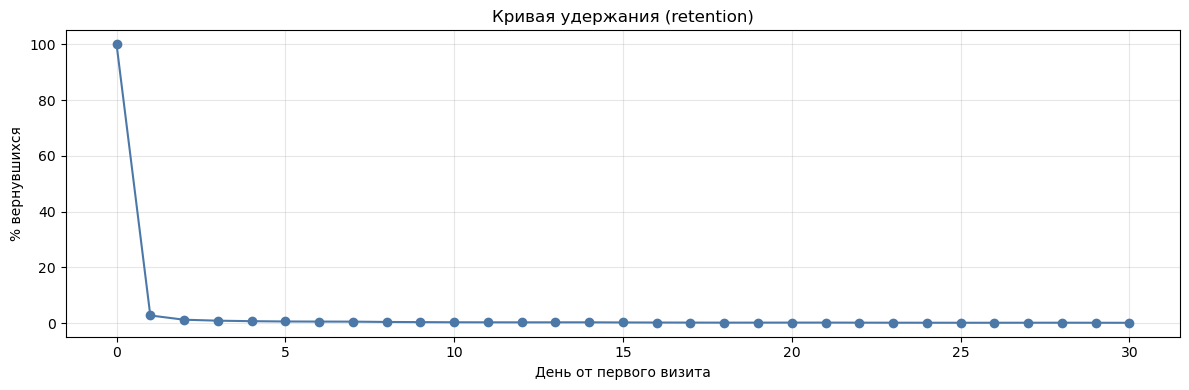

In [34]:
import matplotlib.pyplot as plt

curve = by_day.loc[0:30] / cohort_size * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(curve.index, curve.values, marker="o", color="#4C78A8")
ax.set_title("Кривая удержания (retention)")
ax.set_xlabel("День от первого визита")
ax.set_ylabel("% вернувшихся")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../data/retention.png", dpi=120)
plt.show()

In [35]:
max_day = activity["day"].max()  


users = activity[["visitorid", "first_day"]].drop_duplicates()
users["window"] = (max_day - users["first_day"]).dt.days

print("Retention с поправкой на окно наблюдения:")
for n in [1, 7, 14, 30]:
    eligible = users.loc[users["window"] >= n, "visitorid"]
    denom = len(eligible)
    active_n = activity.loc[activity["day_n"] == n, "visitorid"]
    returned = active_n[active_n.isin(eligible)].nunique()
    print(f"Day {n:>2}: {returned:>7,} / {denom:>7,}  ({returned/denom:.3%})")

Retention с поправкой на окно наблюдения:
Day  1:  38,827 / 1,406,800  (2.760%)
Day  7:   7,610 / 1,357,178  (0.561%)
Day 14:   4,137 / 1,287,901  (0.321%)
Day 30:   1,797 / 1,141,997  (0.157%)
